## Simulating two vessels passing a lock: two opposing vessels
In this notebook, we simulate a lock complex on a network. We model two opposing directed vessels that have to pass the complex. Hence, when one vessel is being levelled, the other vessel has to wait.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core import Movable
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object, inspect_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of util for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.3.1.dev0+g545dd1b5e.d20260507


#### 0. Create environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
The Lock Module works with undirected, directed, and multi-directed graphs. In this example, we use an undirected graph with two nodes (0 and 1), and a single edge of 10 kilometres.

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087') #equidistant WGS84 in meters
wgs84rad = pyproj.CRS('4326') #radial WGS84 (used in GPS)

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.Graph()

# add nodes
geometry_m = Point(-5000,0)
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_node('0',geometry=geometry) #we need to have a geometry in WGS84
geometry_m = Point(5000,0)
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_node('1',geometry=geometry) #we need to have a geometry in WGS84

# add edges
geometry_m = LineString([Point(-5000, 0),Point(5000, 0)])
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_edge('0','1', geometry = geometry, weight=1, length_m=10000) #we need to have a geometry in WGS84 and a length in meters

# add graph to environment
env.graph = graph

We plot the graph

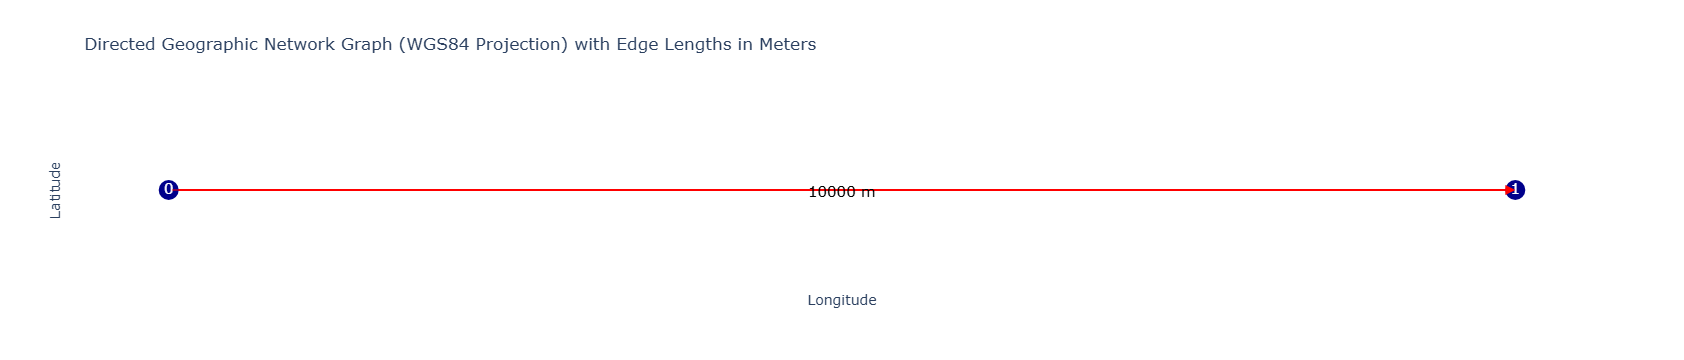

In [4]:
plot_graph(graph)

#### 1+ Adding infrastructure
The <strong>Lock Complex</strong> is an object that facilitates vessels to pass a barrier that is traversable by means of a <strong>Lock Chamber</strong>. The complex has a <strong>Lock Master</strong> that schedules lock operations based on the traffic, and instructs vessels to wait in dedicated waiting areas or proceed to the lock chamber.
<dl>
<dt>The lock complex in OpenTNSim consists of at least the following two objects:</dt>
<dd>1)   A lock chamber;</dd>
<dd>2)   Waiting areas on both sides of the lock chamber.</dd>
</dl>

##### 1) Lock chamber
A Lock Chamber is schematized as a one-dimensional line object with a length capacity, a width and a depth. The chamber should be added to the environment, and a single edge (it cannot be placed on multiple edges), and at least have a name and distances from the lock gates to the edge nodes. More parameters can be added to the object and will be further discussed in the next notebooks. Each lock chamber has a <strong>Lock Operator</strong> that handles all the levelling operations.
<dl>
<dt>There are two ways of creating a lock chamber object:</dt>
<dd>a)   Using chamber dimensions, a selected edge and distances to nodes of the edge (<font color='red'>rule:</font> distances  + lock_length = edge_length);</dd>
<dd>b)   Using a geometry that overlaps the graph: chamber dimensions and distances to nodes of the edge are determined automatically</dd>
</dl>

In [5]:
#We use approach a)
lock_chamber = IsLockChamber(env=env,
                             lock_length = 400,
                             lock_width = 50,
                             lock_depth = 10,
                             name='Lock',      
                             edge = ('0','1'),
                             distance_from_start_node_to_lock_gate_A = 4800.,
                             distance_from_end_node_to_lock_gate_B = 4800.)

##### 2) Waiting areas
Waiting areas are considered as point objects with a certain integer capacity (default = infinity). The waiting areas should be assigned to the environment on an edge, and have a name and a distance to the start of the edge. Like the lock chamber, there are two ways of creating waiting areas object, but here we use a manual setup.

In [6]:
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0, # orientation indicates that waiting area aligns with start node of lock edge (0) or not (1)
                                   distance_from_edge_start = 0) # waiting area A will be located on node 1

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0) # waiting area B will be located on node 1

We add the lock chambers and waiting areas to the lock complex object. This object also needs a name, an environment, and registration nodes. At these nodes, the vessels will register themselves with the lock master. These nodes are the boundaries of the lock complex. All vessels that want to pass the lock complex should move over these nodes. Moreover, all the infrastructure of the lock complex should be within these nodes: a vessel should always pass a registration node, followed by a waiting area and a lock chamber.

In [7]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create agents according to earlier notebooks. To let a vessel interact with a lock complex, it has to be LockComplexTraversable.

In [8]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
        Movable,                    # allows the object to move, with a fixed speed, while logging this activity
    ), 
)

We define a mission for the vessels: to complete their route

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

We can inspect what input is required to create a vessel and which parameters can be optionally added to this vessel:

In [10]:
inspect_object(Vessel, show_parameter_table = True)

,parameter,class,status
0,name,Identifiable,missing
1,geometry,Locatable,missing
2,v,Movable,missing
3,route,Routable,missing
4,env,SimpyObject,missing
5,B,VesselProperties,missing
6,L,VesselProperties,missing
7,T,VesselProperties,missing
8,type,VesselProperties,missing
9,id,Identifiable,optional (unused)


We create two vessels with opposing directions (using the above dataframe)

In [11]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2));

#### 3. Run simulation
We run the simulation

In [12]:
env.run()

#### 4. Inspect output
##### Vessel logbooks
We can inspect the dataframes of the two vessels. Messages emerge that correspond with the lock operation. For vessel 2, we also see waiting time, contributing to the delay to pass the lock.

In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
1,Sailing to first lock gate start,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
2,Sailing to first lock gate stop,2025-01-01 00:20:00.000000,4800.0,POINT (-0.001796630568239 0)
3,Sailing to position in lock start,2025-01-01 00:20:00.000000,4800.0,POINT (-0.001796630568239 0)
4,Sailing to position in lock stop,2025-01-01 00:25:40.172786,5150.0,POINT (0.0013474729261793 0)
5,Waiting for lock gate closing start,2025-01-01 00:25:40.172786,5150.0,POINT (0.0013474729261793 0)
6,Waiting for lock gate closing stop,2025-01-01 00:30:40.172786,5150.0,POINT (0.0013474729261793 0)
7,Waiting for lock levelling start,2025-01-01 00:30:40.172786,5150.0,POINT (0.0013474729261793 0)
8,Waiting for lock levelling stop,2025-01-01 00:40:40.172786,5150.0,POINT (0.0013474729261793 0)
9,Waiting for lock gate opening start,2025-01-01 00:40:40.172786,5150.0,POINT (0.0013474729261793 0)


In [14]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 1 to node 0 start,2025-01-01 00:05:00.000000,0.0,POINT (0.0449157642059761 0)
1,Waiting for lock operation start,2025-01-01 00:05:00.000000,0.0,POINT (0.0449157642059761 0)
2,Waiting for lock operation stop,2025-01-01 00:29:33.768898,0.0,POINT (0.0449157642059761 0)
3,Sailing to first lock gate start,2025-01-01 00:29:33.768898,0.0,POINT (0.0449157642059761 0)
4,Sailing to first lock gate stop,2025-01-01 00:49:33.768898,4800.0,POINT (0.001796630568239 0)
5,Sailing to position in lock start,2025-01-01 00:49:33.768898,4800.0,POINT (0.001796630568239 0)
6,Sailing to position in lock stop,2025-01-01 00:55:13.941684,5150.0,POINT (-0.0013474729261793 0)
7,Waiting for lock gate closing start,2025-01-01 00:55:13.941685,5150.0,POINT (-0.0013474729261793 0)
8,Waiting for lock gate closing stop,2025-01-01 01:00:13.941685,5150.0,POINT (-0.0013474729261793 0)
9,Waiting for lock levelling start,2025-01-01 01:00:13.941685,5150.0,POINT (-0.0013474729261793 0)


##### Lock chamber logbook
The lock chamber also has a log which we can inspect. Messages consist of gate closing, converting (levelling), and gate opening. There are two operations.

In [15]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock_chamber.logbook)

print("'{}' logbook data:".format(lock_chamber.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 00:25:40.172786,0,POLYGON ((0.001796630568239 0.0002245788210299...
1,Lock gate closing stop,2025-01-01 00:30:40.172786,0,POLYGON ((0.001796630568239 0.0002245788210299...
2,Lock levelling start,2025-01-01 00:30:40.172786,0,POLYGON ((0.001796630568239 0.0002245788210299...
3,Lock levelling stop,2025-01-01 00:40:40.172786,1,POLYGON ((0.001796630568239 0.0002245788210299...
4,Lock gate opening start,2025-01-01 00:40:40.172786,1,POLYGON ((0.001796630568239 0.0002245788210299...
5,Lock gate opening stop,2025-01-01 00:45:40.172786,1,POLYGON ((0.001796630568239 0.0002245788210299...
6,Lock gate closing start,2025-01-01 00:55:13.941685,1,POLYGON ((0.001796630568239 0.0002245788210299...
7,Lock gate closing stop,2025-01-01 01:00:13.941685,1,POLYGON ((0.001796630568239 0.0002245788210299...
8,Lock levelling start,2025-01-01 01:00:13.941685,1,POLYGON ((0.001796630568239 0.0002245788210299...
9,Lock levelling stop,2025-01-01 01:10:13.941685,0,POLYGON ((0.001796630568239 0.0002245788210299...


##### Time-distance diagram
Lock chambers also have time-distance diagram plots, in which we can inspect the trajectories of the vessels and the lock chamber operation phases. We can now better understand why waiting time emerged for the second vessel. Vessels pass at 300 meters from the lock (by default).

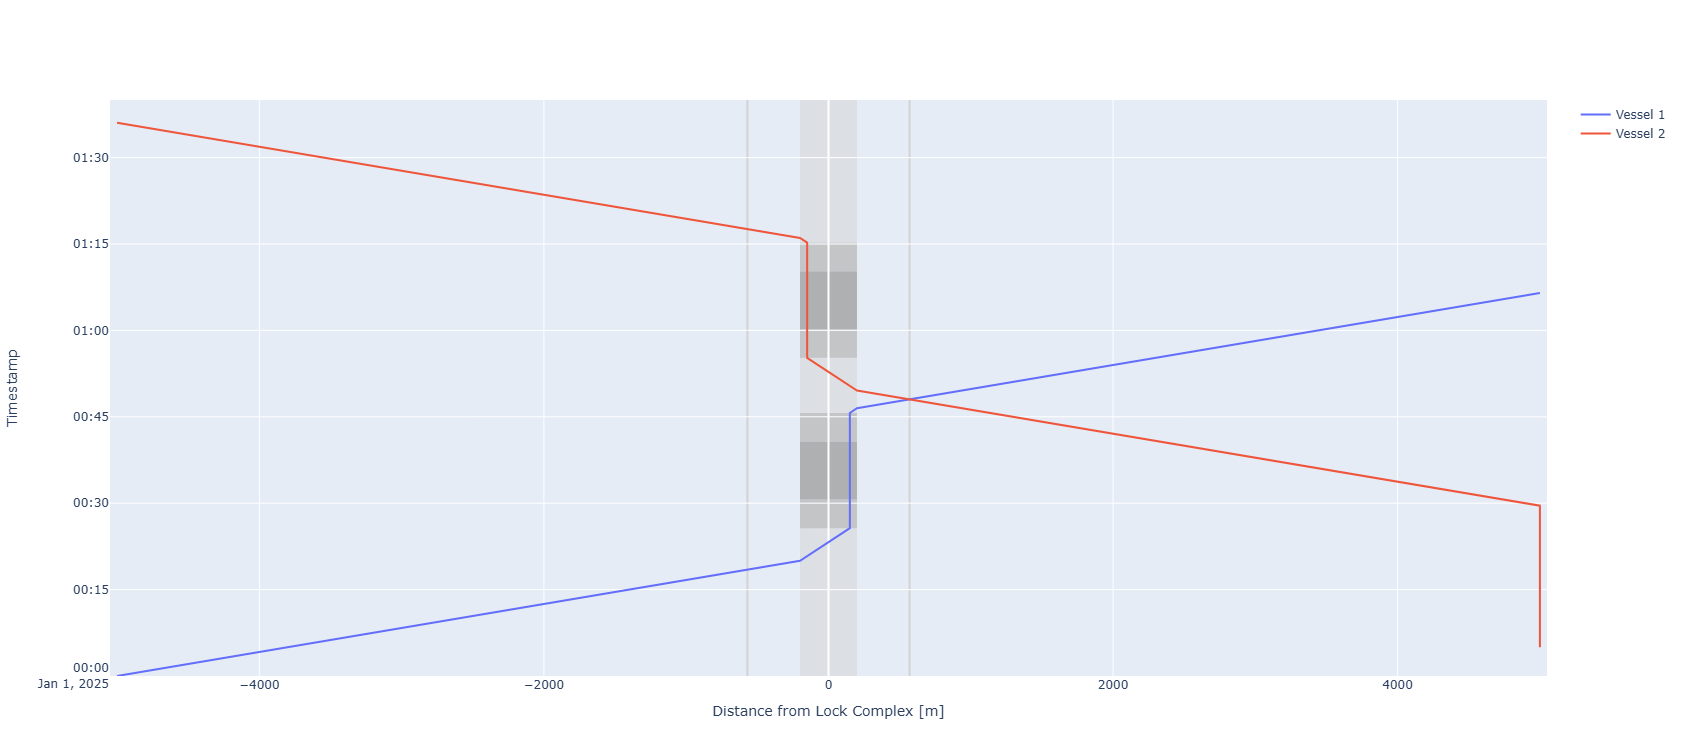

In [16]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -5050, 
                        xlimmax = 5050, 
                        ylimmin = datetime.datetime(2025, 1, 1, 0, 0, 0),
                        ylimmax = datetime.datetime(2025, 1, 1, 1, 40, 0),
                        method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

##### Event chart
We can also create a Gantt chart based on an event table of the vessels and the lock chamber. We see that the time to pass the edge with the lock chamber becomes variable. Moreover, we observe a cyclic behaviour of the lock chamber.

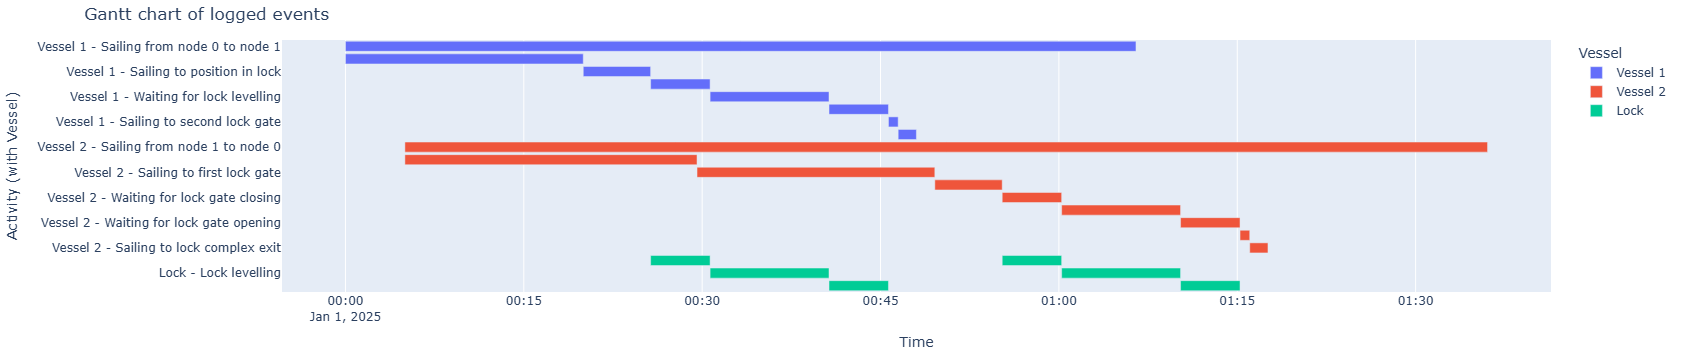

In [17]:
df_eventtable = logbook2eventtable([vessel_1, vessel_2, lock_chamber])
generate_vessel_gantt_chart(df_eventtable)

##### Plannings
We can also get the lock operation and vessel planning of the lock master:

In [18]:
lock_complex.operation_planning

,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
0,0,1,0,Lock,0,[<opentnsim.core.utils.Vessel object at 0x0000...,300,50,2025-01-01 00:10:00,2025-01-01 00:18:27.500000,...,2025-01-01 00:45:40.172786470,2025-01-01 00:45:40.172786470,2025-01-01 00:46:28.768898822,2025-01-01 00:48:01.268898822,2025-01-01 00:48:28.768898822,NaN,NaN,NaN,NaN,processed
1,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,300,50,2025-01-01 00:39:33.768898822,2025-01-01 00:48:01.268898822,...,2025-01-01 01:15:13.941685292,2025-01-01 01:15:13.941685292,2025-01-01 01:16:02.537797644,2025-01-01 01:17:35.037797644,2025-01-01 01:18:02.537797644,NaN,NaN,NaN,NaN,processed


In [19]:
lock_complex.vessel_planning

,id,node_from,node_to,direction,waiting_area,lineup_area,lock_chamber,L,B,T,...,time_arrival_at_approach_point,time_lock_operation_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,time_to_traverse_waterway_without_lock,delay
0,c2154ba5-acb8-4b9d-bf9d-73866a8a7055,0,1,0,Waiting area A,None,Lock,100,20,5,...,2025-01-01 00:18:27.500000,2025-01-01 00:18:27.500000,2025-01-01 00:20:00,2025-01-01 00:25:40.172786470,2025-01-01 00:45:40.172786470,2025-01-01 00:46:28.768898822,2025-01-01 00:48:01.268898822,2025-01-01 00:48:28.768898822,2025-01-01 00:41:40,0 days 00:00:00
1,f82e5a19-2173-4fc2-ac74-5416b5b8094e,1,0,1,Waiting area B,None,Lock,100,20,5,...,2025-01-01 00:48:01.268898822,2025-01-01 00:48:01.268898822,2025-01-01 00:49:33.768898822,2025-01-01 00:55:13.941685292,2025-01-01 01:15:13.941685292,2025-01-01 01:16:02.537797644,2025-01-01 01:17:35.037797644,2025-01-01 01:18:02.537797644,2025-01-01 00:46:40,0 days 00:00:00
